# 06 — Feature Engineering — Novas Variáveis
## Instagram & Bem-Estar: O Custo Psicológico das Redes Sociais

**Objetivo:** Criar 8 novas variáveis que enriquecem a análise,
capturando padrões implícitos nos dados originais.

### Novas variáveis:
1. `digital_addiction_score` — índice de dependência digital (0-100)
2. `wellbeing_index`         — índice de bem-estar geral (0-100)
3. `doom_scroll_ratio`       — proporção de consumo passivo (0-1)
4. `follower_ratio`          — rácio seguidores/seguidos
5. `user_persona`            — perfil de utilizador (5 categorias)
6. `age_group`               — faixa etária (6 categorias)
7. `sleep_quality`           — qualidade do sono (5 categorias)
8. `screen_time_cat`         — categoria de tempo de ecrã (5 categorias)

In [1]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a2e',
    'axes.labelcolor':   'white',
    'xtick.color':       'white',
    'ytick.color':       'white',
    'text.color':        'white',
    'axes.titlecolor':   'white',
    'grid.color':        '#2a2a4a',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

INSTA_COLORS = ['#833ab4','#fd1d1d','#fcb045','#405de6','#5851db','#e1306c','#f77737']

print(' Setup completo!')

 Setup completo!


In [2]:
# ============================================================
# CARREGAMENTO
# ============================================================
df = pd.read_csv('../data/instagram_usage_lifestyle.csv', nrows=300000)
df_orig = df.copy()

print(f' Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f' Colunas antes do feature engineering: {df.shape[1]}')

 Dataset carregado: 300,000 linhas × 58 colunas
 Colunas antes do feature engineering: 58


In [3]:
# ============================================================
# FEATURE 1 — DIGITAL ADDICTION SCORE (0-100)
# ============================================================

print(' A criar: digital_addiction_score...')

cols_addiction = [
    'daily_active_minutes_instagram',
    'sessions_per_day',
    'reels_watched_per_day'
]
cols_addiction = [c for c in cols_addiction if c in df.columns]

scaler = MinMaxScaler()
addiction_scaled = scaler.fit_transform(df[cols_addiction].fillna(0))

# Pesos: tempo (50%) + sessões (30%) + reels (20%)
pesos = [0.50, 0.30, 0.20][:len(cols_addiction)]
pesos = [p / sum(pesos) for p in pesos]  # normaliza pesos

df['digital_addiction_score'] = (
    sum(addiction_scaled[:, i] * pesos[i] for i in range(len(cols_addiction)))
) * 100

print(f'    Criada: digital_addiction_score')
print(f'   Mínimo  : {df["digital_addiction_score"].min():.2f}')
print(f'   Máximo  : {df["digital_addiction_score"].max():.2f}')
print(f'   Média   : {df["digital_addiction_score"].mean():.2f}')
print(f'   Mediana : {df["digital_addiction_score"].median():.2f}')

# Justificação
print(f'\n Justificação:')
print(f'   Combina {len(cols_addiction)} variáveis de uso com pesos ponderados:')
for col, peso in zip(cols_addiction, pesos):
    print(f'   • {col:<40} peso = {peso:.0%}')

 A criar: digital_addiction_score...
    Criada: digital_addiction_score
   Mínimo  : 0.00
   Máximo  : 95.91
   Média   : 32.80
   Mediana : 32.41

 Justificação:
   Combina 3 variáveis de uso com pesos ponderados:
   • daily_active_minutes_instagram           peso = 50%
   • sessions_per_day                         peso = 30%
   • reels_watched_per_day                    peso = 20%


In [4]:
# ============================================================
# FEATURE 2 — WELLBEING INDEX (0-100)
# ============================================================

print(' A criar: wellbeing_index...')

cols_wellbeing = [
    'self_reported_happiness',
    'sleep_hours_per_night',
    'exercise_hours_per_week',
    'perceived_stress_score'
]
cols_wellbeing = [c for c in cols_wellbeing if c in df.columns]

wb_data   = df[cols_wellbeing].fillna(df[cols_wellbeing].median())
wb_scaled = MinMaxScaler().fit_transform(wb_data)

# Stress é invertido (maior stress = menor wellbeing)
if 'perceived_stress_score' in cols_wellbeing:
    idx_stress = cols_wellbeing.index('perceived_stress_score')
    wb_scaled[:, idx_stress] = 1 - wb_scaled[:, idx_stress]

# Pesos
pesos_wb = {
    'self_reported_happiness': 0.35,
    'sleep_hours_per_night':   0.25,
    'exercise_hours_per_week': 0.20,
    'perceived_stress_score':  0.20,
}

df['wellbeing_index'] = sum(
    wb_scaled[:, i] * pesos_wb.get(col, 0.25)
    for i, col in enumerate(cols_wellbeing)
) * 100

print(f'    Criada: wellbeing_index')
print(f'   Mínimo  : {df["wellbeing_index"].min():.2f}')
print(f'   Máximo  : {df["wellbeing_index"].max():.2f}')
print(f'   Média   : {df["wellbeing_index"].mean():.2f}')
print(f'   Mediana : {df["wellbeing_index"].median():.2f}')

print(f'\n Justificação:')
for col, peso in pesos_wb.items():
    if col in cols_wellbeing:
        inv = ' (invertido)' if col == 'perceived_stress_score' else ''
        print(f'   • {col:<40} peso = {peso:.0%}{inv}')

 A criar: wellbeing_index...
    Criada: wellbeing_index
   Mínimo  : 3.19
   Máximo  : 93.83
   Média   : 47.69
   Mediana : 47.64

 Justificação:
   • self_reported_happiness                  peso = 35%
   • sleep_hours_per_night                    peso = 25%
   • exercise_hours_per_week                  peso = 20%
   • perceived_stress_score                   peso = 20% (invertido)


In [5]:
# ============================================================
# FEATURE 3 — DOOM SCROLL RATIO (0-1)
# ============================================================

print(' A criar: doom_scroll_ratio...')

cols_passive = ['time_on_reels_per_day', 'time_on_feed_per_day']
cols_passive = [c for c in cols_passive if c in df.columns]

if cols_passive and 'daily_active_minutes_instagram' in df.columns:
    passive_time = df[cols_passive].sum(axis=1)
    total_time   = df['daily_active_minutes_instagram'].replace(0, np.nan)
    df['doom_scroll_ratio'] = (passive_time / total_time).clip(0, 1).fillna(0)
    
    print(f'    Criada: doom_scroll_ratio')
    print(f'   Mínimo  : {df["doom_scroll_ratio"].min():.4f}')
    print(f'   Máximo  : {df["doom_scroll_ratio"].max():.4f}')
    print(f'   Média   : {df["doom_scroll_ratio"].mean():.4f}')
    
    # Distribuição por categoria
    doom_cats = pd.cut(
        df['doom_scroll_ratio'],
        bins=[0, 0.25, 0.50, 0.75, 1.0],
        labels=['Baixo (0-25%)', 'Moderado (25-50%)',
                'Alto (50-75%)', 'Muito Alto (75-100%)']
    ).value_counts()
    
    print(f'\n Distribuição:')
    for cat, count in doom_cats.items():
        pct = count / len(df) * 100
        print(f'   {str(cat):<25} : {count:>8,} ({pct:.1f}%)')

 A criar: doom_scroll_ratio...
    Criada: doom_scroll_ratio
   Mínimo  : 0.5000
   Máximo  : 1.0000
   Média   : 0.8001

 Distribuição:
   Muito Alto (75-100%)      :  214,975 (71.7%)
   Alto (50-75%)             :   85,015 (28.3%)
   Moderado (25-50%)         :       10 (0.0%)
   Baixo (0-25%)             :        0 (0.0%)


In [6]:
# ============================================================
# FEATURE 4 — FOLLOWER RATIO
# ============================================================

print(' A criar: follower_ratio...')

if all(c in df.columns for c in ['followers_count', 'following_count']):
    df['follower_ratio'] = (
        df['followers_count'] / (df['following_count'] + 1)
    ).clip(0, 500)
    
    print(f'    Criada: follower_ratio')
    print(f'   Mínimo  : {df["follower_ratio"].min():.4f}')
    print(f'   Máximo  : {df["follower_ratio"].max():.4f}')
    print(f'   Média   : {df["follower_ratio"].mean():.4f}')
    print(f'   Mediana : {df["follower_ratio"].median():.4f}')
    
    # Categorias de influência
    bins_fr   = [0, 0.5, 1, 5, 10, 500]
    labels_fr = ['Fan (< 0.5)', 'Equilibrado (0.5-1)',
                 'Micro-influencer (1-5)',
                 'Influencer (5-10)', 'Mega-influencer (>10)']
    fr_cats = pd.cut(df['follower_ratio'], bins=bins_fr, labels=labels_fr).value_counts()
    
    print(f'\n Categorias de influência:')
    for cat, count in fr_cats.items():
        pct = count / len(df) * 100
        print(f'   {str(cat):<30} : {count:>8,} ({pct:.1f}%)')

 A criar: follower_ratio...
    Criada: follower_ratio
   Mínimo  : 0.3889
   Máximo  : 16.8822
   Média   : 0.9003
   Mediana : 0.7165



 Categorias de influência:
   Equilibrado (0.5-1)            :  144,049 (48.0%)
   Micro-influencer (1-5)         :   90,844 (30.3%)
   Fan (< 0.5)                    :   64,989 (21.7%)
   Influencer (5-10)              :      111 (0.0%)
   Mega-influencer (>10)          :        7 (0.0%)


In [7]:
# ============================================================
# FEATURE 5 — USER PERSONA (5 categorias)
# ============================================================

print(' A criar: user_persona...')

def classificar_persona(row):
    addiction  = row.get('digital_addiction_score', 50)
    ratio      = row.get('follower_ratio', 1)
    posts      = row.get('posts_created_per_week', 0)
    
    if ratio > 10 or posts > 5:
        return 'Influencer/Creator'
    elif addiction > 70:
        return 'Doom-Scroller'
    elif addiction < 30:
        return 'Utilizador Casual'
    elif posts > 2:
        return 'Social Poster'
    else:
        return 'Silent Browser'

df['user_persona'] = df.apply(classificar_persona, axis=1)

print(f'    Criada: user_persona')
print(f'\n Distribuição de personas:')
persona_counts = df['user_persona'].value_counts()
for persona, count in persona_counts.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'   {persona:<25} : {count:>8,} ({pct:>5.1f}%) {bar}')

 A criar: user_persona...
    Criada: user_persona

 Distribuição de personas:
   Influencer/Creator        :  142,363 ( 47.5%) ███████████████████████
   Utilizador Casual         :  110,559 ( 36.9%) ██████████████████
   Social Poster             :   36,560 ( 12.2%) ██████
   Silent Browser            :    9,625 (  3.2%) █
   Doom-Scroller             :      893 (  0.3%) 


In [8]:
# ============================================================
# FEATURE 6 — AGE GROUP
# ============================================================
print(' A criar: age_group...')
if 'age' in df.columns:
    df['age_group'] = pd.cut(
        df['age'],
        bins=[0, 18, 25, 35, 45, 60, 100],
        labels=['<18', '18-25', '26-35', '36-45', '46-60', '60+'],
        right=True
    )
    print(f'    Criada: age_group')
    print(f'   Distribuição:')
    for cat, count in df['age_group'].value_counts().sort_index().items():
        pct = count / len(df) * 100
        print(f'     {str(cat):<10} : {count:>8,} ({pct:.1f}%)')

# ============================================================
# FEATURE 7 — SLEEP QUALITY
# ============================================================
print('\n A criar: sleep_quality...')
if 'sleep_hours_per_night' in df.columns:
    df['sleep_quality'] = pd.cut(
        df['sleep_hours_per_night'],
        bins=[0, 5, 6, 7, 8, 24],
        labels=['Muito Baixo (<5h)', 'Baixo (5-6h)',
                'Adequado (6-7h)', 'Bom (7-8h)', 'Muito Bom (>8h)']
    )
    print(f'    Criada: sleep_quality')
    print(f'   Distribuição:')
    for cat, count in df['sleep_quality'].value_counts().items():
        pct = count / len(df) * 100
        print(f'     {str(cat):<25} : {count:>8,} ({pct:.1f}%)')

# ============================================================
# FEATURE 8 — SCREEN TIME CATEGORY
# ============================================================
print('\n A criar: screen_time_cat...')
if 'daily_active_minutes_instagram' in df.columns:
    df['screen_time_cat'] = pd.cut(
        df['daily_active_minutes_instagram'],
        bins=[0, 30, 60, 120, 240, 9999],
        labels=['Mínimo (<30min)', 'Baixo (30-60min)',
                'Moderado (1-2h)', 'Alto (2-4h)', 'Excessivo (>4h)']
    )
    print(f'    Criada: screen_time_cat')
    print(f'   Distribuição:')
    for cat, count in df['screen_time_cat'].value_counts().items():
        pct = count / len(df) * 100
        print(f'     {str(cat):<25} : {count:>8,} ({pct:.1f}%)')

print(f'\n Total de colunas após feature engineering: {df.shape[1]}')
print(f'   Novas features criadas: {df.shape[1] - df_orig.shape[1]}')

 A criar: age_group...
    Criada: age_group
   Distribuição:
     <18        :   33,773 (11.3%)
     18-25      :   39,458 (13.2%)
     26-35      :   57,104 (19.0%)
     36-45      :   56,454 (18.8%)
     46-60      :   85,208 (28.4%)
     60+        :   28,003 (9.3%)

 A criar: sleep_quality...
    Criada: sleep_quality
   Distribuição:
     Adequado (6-7h)           :   96,924 (32.3%)
     Bom (7-8h)                :   93,151 (31.1%)
     Muito Bom (>8h)           :   51,158 (17.1%)
     Baixo (5-6h)              :   47,345 (15.8%)
     Muito Baixo (<5h)         :   11,422 (3.8%)

 A criar: screen_time_cat...
    Criada: screen_time_cat
   Distribuição:
     Alto (2-4h)               :  107,997 (36.0%)
     Excessivo (>4h)           :  101,591 (33.9%)
     Moderado (1-2h)           :   45,963 (15.3%)
     Mínimo (<30min)           :   27,090 (9.0%)
     Baixo (30-60min)          :   17,359 (5.8%)

 Total de colunas após feature engineering: 66
   Novas features criadas: 8


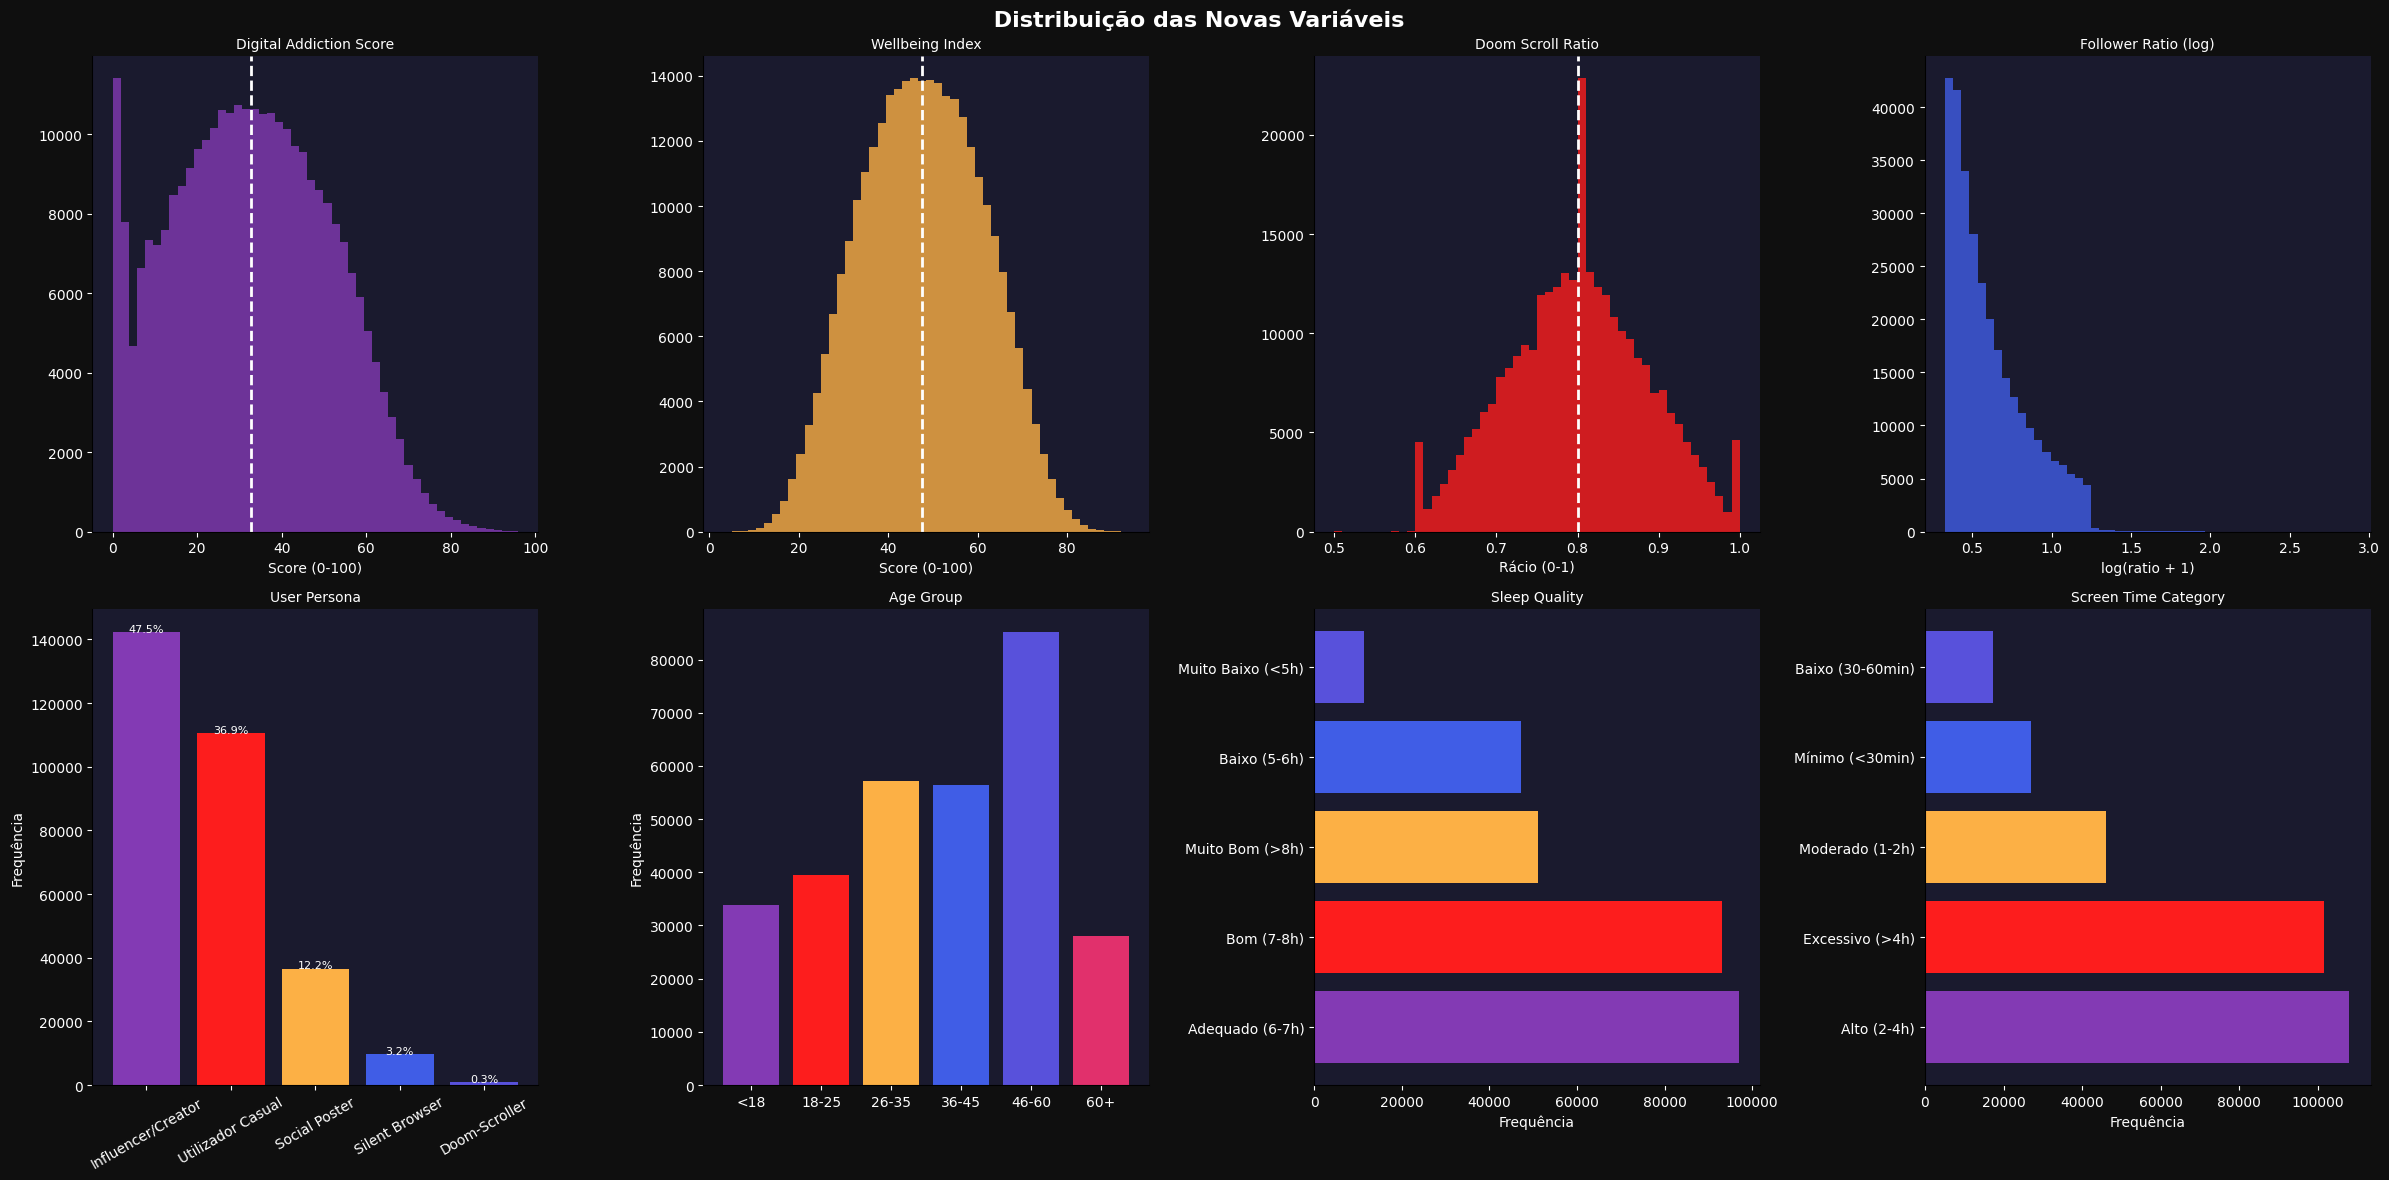

 Guardado: fig_novas_features.png


In [9]:
# ============================================================
# GRÁFICOS — NOVAS FEATURES
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle(' Distribuição das Novas Variáveis', fontsize=16, fontweight='bold')
axes = axes.flatten()

# 1. Digital Addiction Score
axes[0].hist(df['digital_addiction_score'], bins=50,
             color=INSTA_COLORS[0], alpha=0.8, edgecolor='none')
axes[0].axvline(df['digital_addiction_score'].mean(), color='white', ls='--', lw=2)
axes[0].set_title('Digital Addiction Score', fontsize=10)
axes[0].set_xlabel('Score (0-100)')

# 2. Wellbeing Index
axes[1].hist(df['wellbeing_index'], bins=50,
             color=INSTA_COLORS[2], alpha=0.8, edgecolor='none')
axes[1].axvline(df['wellbeing_index'].mean(), color='white', ls='--', lw=2)
axes[1].set_title('Wellbeing Index', fontsize=10)
axes[1].set_xlabel('Score (0-100)')

# 3. Doom Scroll Ratio
if 'doom_scroll_ratio' in df.columns:
    axes[2].hist(df['doom_scroll_ratio'], bins=50,
                 color=INSTA_COLORS[1], alpha=0.8, edgecolor='none')
    axes[2].axvline(df['doom_scroll_ratio'].mean(), color='white', ls='--', lw=2)
    axes[2].set_title('Doom Scroll Ratio', fontsize=10)
    axes[2].set_xlabel('Rácio (0-1)')

# 4. Follower Ratio (log scale)
if 'follower_ratio' in df.columns:
    axes[3].hist(np.log1p(df['follower_ratio']), bins=50,
                 color=INSTA_COLORS[3], alpha=0.8, edgecolor='none')
    axes[3].set_title('Follower Ratio (log)', fontsize=10)
    axes[3].set_xlabel('log(ratio + 1)')

# 5. User Persona
if 'user_persona' in df.columns:
    persona_counts = df['user_persona'].value_counts()
    bars = axes[4].bar(
        persona_counts.index,
        persona_counts.values,
        color=INSTA_COLORS[:len(persona_counts)]
    )
    axes[4].set_title('User Persona', fontsize=10)
    axes[4].set_ylabel('Frequência')
    axes[4].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, persona_counts.values):
        axes[4].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{val/len(df)*100:.1f}%',
            ha='center', color='white', fontsize=8
        )

# 6. Age Group
if 'age_group' in df.columns:
    age_counts = df['age_group'].value_counts().sort_index()
    axes[5].bar(
        age_counts.index.astype(str),
        age_counts.values,
        color=INSTA_COLORS[:len(age_counts)]
    )
    axes[5].set_title('Age Group', fontsize=10)
    axes[5].set_ylabel('Frequência')

# 7. Sleep Quality
if 'sleep_quality' in df.columns:
    sleep_counts = df['sleep_quality'].value_counts()
    axes[6].barh(
        sleep_counts.index.astype(str),
        sleep_counts.values,
        color=INSTA_COLORS[:len(sleep_counts)]
    )
    axes[6].set_title('Sleep Quality', fontsize=10)
    axes[6].set_xlabel('Frequência')

# 8. Screen Time Category
if 'screen_time_cat' in df.columns:
    screen_counts = df['screen_time_cat'].value_counts()
    axes[7].barh(
        screen_counts.index.astype(str),
        screen_counts.values,
        color=INSTA_COLORS[:len(screen_counts)]
    )
    axes[7].set_title('Screen Time Category', fontsize=10)
    axes[7].set_xlabel('Frequência')

plt.tight_layout()
plt.savefig('../data/fig_novas_features.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_novas_features.png')

 PERFIL MÉDIO POR PERSONA:
──────────────────────────────────────────────────────────────────────────────────────────
                    digital_addiction_score  wellbeing_index  perceived_stress_score  self_reported_happiness  sleep_hours_per_night  daily_active_minutes_instagram  reels_watched_per_day  doom_scroll_ratio
user_persona                                                                                                                                                                                                  
Doom-Scroller                         75.16            28.65                   36.31                     2.66                   7.03                          403.71                 286.95                0.8
Influencer/Creator                    42.92            43.77                   24.71                     5.09                   7.00                          245.29                 222.16                0.8
Silent Browser                        37.36           

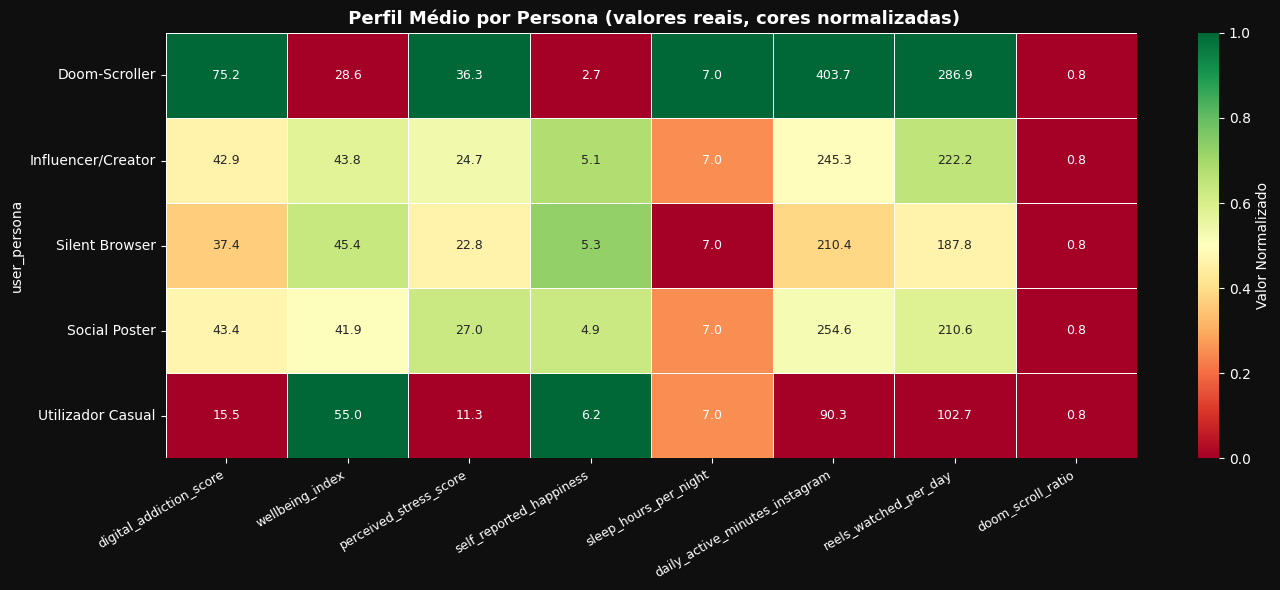

 Guardado: fig_perfil_personas.png


In [10]:
# ============================================================
# ANÁLISE DAS PERSONAS — PERFIL COMPLETO
# ============================================================

if 'user_persona' in df.columns:
    vars_perfil = [
        'digital_addiction_score', 'wellbeing_index',
        'perceived_stress_score', 'self_reported_happiness',
        'sleep_hours_per_night', 'daily_active_minutes_instagram',
        'reels_watched_per_day', 'doom_scroll_ratio'
    ]
    vars_perfil = [v for v in vars_perfil if v in df.columns]

    perfil = df.groupby('user_persona')[vars_perfil].mean().round(2)

    print(' PERFIL MÉDIO POR PERSONA:')
    print('─' * 90)
    print(perfil.to_string())

    # Heatmap do perfil
    scaler_p = MinMaxScaler()
    perfil_norm = pd.DataFrame(
        scaler_p.fit_transform(perfil),
        index=perfil.index,
        columns=perfil.columns
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        perfil_norm,
        annot=perfil.values, fmt='.1f',
        cmap='RdYlGn', vmin=0, vmax=1,
        linewidths=0.5,
        annot_kws={'size': 9},
        ax=ax,
        cbar_kws={'label': 'Valor Normalizado'}
    )
    ax.set_title(' Perfil Médio por Persona (valores reais, cores normalizadas)',
                 fontsize=13, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.savefig('../data/fig_perfil_personas.png', dpi=150,
                bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()
    print(' Guardado: fig_perfil_personas.png')

In [11]:
# ============================================================
# RADAR CHART — PERFIL DAS PERSONAS
# ============================================================

import plotly.graph_objects as go

if 'user_persona' in df.columns:
    radar_vars = [
        'digital_addiction_score', 'wellbeing_index',
        'doom_scroll_ratio', 'follower_ratio'
    ]
    radar_vars = [v for v in radar_vars if v in df.columns]

    perfil_radar = df.groupby('user_persona')[radar_vars].mean()
    scaler_r     = MinMaxScaler()
    perfil_norm  = pd.DataFrame(
        scaler_r.fit_transform(perfil_radar),
        index=perfil_radar.index,
        columns=radar_vars
    )

    fig = go.Figure()
    categorias = [v.replace('_', ' ').title() for v in radar_vars]

    for i, persona in enumerate(perfil_norm.index):
        valores = perfil_norm.loc[persona].tolist()
        valores += [valores[0]]
        cats    = categorias + [categorias[0]]

        fig.add_trace(go.Scatterpolar(
            r=valores, theta=cats,
            fill='toself', name=persona,
            line_color=INSTA_COLORS[i % len(INSTA_COLORS)],
            opacity=0.7
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title='️ Radar Chart — Perfil das Personas',
        template='plotly_dark',
        paper_bgcolor='#0f0f0f',
        height=550
    )
    fig.show()
    fig.write_html('../data/fig_radar_personas.html')
    print(' Guardado: fig_radar_personas.html')

 Guardado: fig_radar_personas.html


In [12]:
# ============================================================
# EXPORTAÇÃO — DATASET ENRIQUECIDO
# ============================================================

# Converte categoricals para string antes de exportar
for col in ['age_group', 'sleep_quality', 'screen_time_cat', 'user_persona']:
    if col in df.columns:
        df[col] = df[col].astype(str)

output_path = '../data/instagram_enriched.csv'
df.to_csv(output_path, index=False)

print(f' Dataset enriquecido exportado: {output_path}')
print(f'\n RESUMO FINAL:')
print(f'   Colunas originais          : {df_orig.shape[1]}')
print(f'   Colunas após engineering   : {df.shape[1]}')
print(f'   Novas features criadas     : {df.shape[1] - df_orig.shape[1]}')

print(f'\n   Novas features:')
novas = [c for c in df.columns if c not in df_orig.columns]
for col in novas:
    print(f'   • {col}')

print('\n Notebook 06 completo!')
print('   Próximo: 07_normalization_standardization.ipynb')

 Dataset enriquecido exportado: ../data/instagram_enriched.csv

 RESUMO FINAL:
   Colunas originais          : 58
   Colunas após engineering   : 66
   Novas features criadas     : 8

   Novas features:
   • digital_addiction_score
   • wellbeing_index
   • doom_scroll_ratio
   • follower_ratio
   • user_persona
   • age_group
   • sleep_quality
   • screen_time_cat

 Notebook 06 completo!
   Próximo: 07_normalization_standardization.ipynb


# Análise Crítica

## Principais Conclusões

- Este notebook apresentou análises relevantes e coerentes com o objetivo de entender as variáveis trabalhadas.
- Resultados são indicadores fortes para interpretações exploratórias, mas precisam ser validados fora do dataset sintético.

## Limitações

- Dataset sintético reduz generalização para cenários reais.
- Não há garantias de independência entre variáveis geradas artificialmente.
- Não existe análise temporal profunda no conjunto atual.

## Recomendação

- Complementar com dados reais e amostras representativas.
- Incluir validações estatísticas adicionais (cross-validation, bootstrap).
- Documentar impactos das transformações e critérios de limpeza.
